In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import find_boundaries
from skimage.color import label2rgb


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from skimage.color import label2rgb

def _as_float_img(img):
    img = np.asarray(img)
    if img.dtype == np.uint8:
        return (img.astype(np.float32) / 255.0)
    if img.dtype in (np.float16, np.float32, np.float64):
        return img.astype(np.float32, copy=False)
    return img.astype(np.float32)

def _as_int_labels(lbl):
    # label images: int32 propre (0..K)
    if lbl is None:
        return None
    lbl = np.asarray(lbl)
    if lbl.dtype == np.bool_:
        return lbl.astype(np.uint8)
    return lbl.astype(np.int32, copy=False)

def show_overlay(img, inst_pred=None, inst_gt=None, title="", alpha=0.3):
    img_vis = _as_float_img(img)

    inst_pred = _as_int_labels(inst_pred)
    inst_gt   = _as_int_labels(inst_gt)

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img_vis)
    ax.set_title(title)
    ax.axis("off")

    if inst_gt is not None:
        b_gt = find_boundaries(inst_gt, mode="outer").astype(np.uint8)
        # rouge
        ax.imshow(np.dstack([b_gt, np.zeros_like(b_gt), np.zeros_like(b_gt)]).astype(np.float32), alpha=0.5)

    if inst_pred is not None:
        # label2rgb aime bien image float, labels int
        pred_rgb = label2rgb(inst_pred, image=img_vis, bg_label=0, alpha=alpha)
        ax.imshow(pred_rgb)

        b_pr = find_boundaries(inst_pred, mode="outer").astype(np.uint8)
        # vert
        ax.imshow(np.dstack([np.zeros_like(b_pr), b_pr, np.zeros_like(b_pr)]).astype(np.float32), alpha=0.5)

    plt.show()


img_002621.npy (256, 256, 3) (256, 256) 8


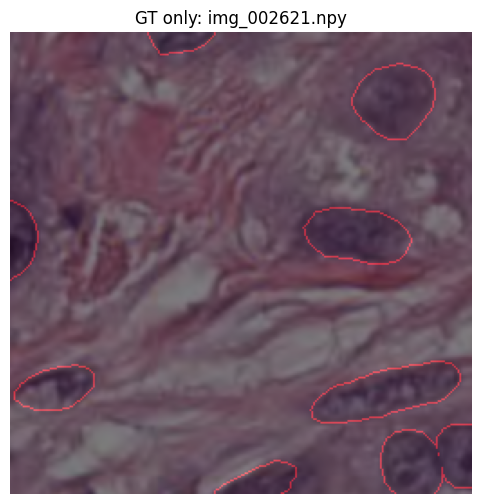

In [15]:
from pathlib import Path
from src.pannuke_dataset import PannukePreparedDataset

DATA_ROOT = Path("data/prepared/pannuke")  # ajuste si besoin
ds_val = PannukePreparedDataset(DATA_ROOT, split="val", transform=None, return_image_name=True)

img_t, gt_inst_t, types_t, name = ds_val[0]
img = img_t.permute(1,2,0).numpy()          # (H,W,3)
gt_inst = gt_inst_t.numpy().astype(np.int32)

print(name, img.shape, gt_inst.shape, gt_inst.max())
show_overlay(img, inst_gt=gt_inst, title=f"GT only: {name}")


In [16]:
# Unet overlay

import torch
from models.lit_unet_pannuke import UNetLightning

ckpt_path = "models/checkpoints/unet_pannuke_lit_best.ckpt"
unet = UNetLightning.load_from_checkpoint(ckpt_path)
unet.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
unet.to(device)

with torch.no_grad():
    x = img_t.unsqueeze(0).to(device)  # (1,3,H,W)
    logits = unet(x)                   # (1,1,H,W)
    prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy().astype(np.float32)
print(prob.min(), prob.max())


8.4271684e-10 0.9980659


pred_unet_inst: 10


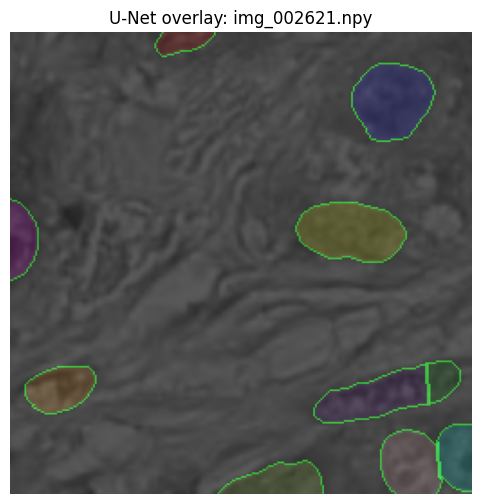

In [17]:
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)
    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)

pred_unet_inst = unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5)
print("pred_unet_inst:", pred_unet_inst.max())
show_overlay(img, inst_pred=pred_unet_inst, inst_gt=gt_inst, title=f"U-Net overlay: {name}")


pred_sd_inst: 17


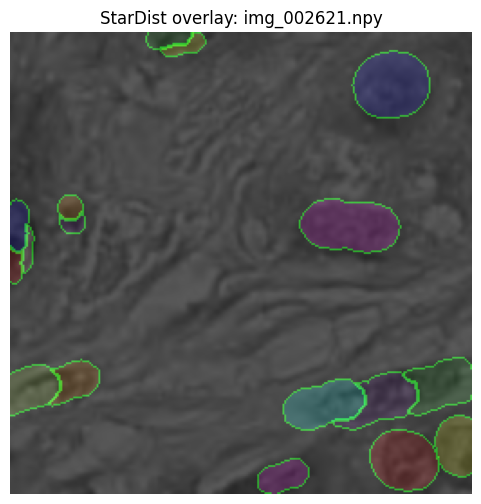

In [18]:
from models.stardist import StarDist, stardist_decode  # adapte si besoin

N_RAYS = 32
stard_ckpt = "models/checkpoints/stardist_pannuke_routeB_best.ckpt"

# si ton StarDist est dans Lightning: load_from_checkpoint
from models.lit_stardist_pannuke import StarDistLightning  # adapte
stard = StarDistLightning.load_from_checkpoint(stard_ckpt)
stard.eval()
stard.to(device)

with torch.no_grad():
    x = img_t.unsqueeze(0).to(device)
    out = stard(x)[0].detach().cpu().numpy()  # (1+R,H,W)

prob_map = 1.0/(1.0 + np.exp(-out[0]))        # sigmoid
dist_map = out[1:].astype(np.float32)         # (R,H,W)

pred_sd_inst = stardist_decode(
    prob_map=prob_map,
    dist_map=dist_map,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    min_area=10,
    max_candidates=3000,
)

print("pred_sd_inst:", pred_sd_inst.max())
show_overlay(img, inst_pred=pred_sd_inst, inst_gt=gt_inst, title=f"StarDist overlay: {name}")


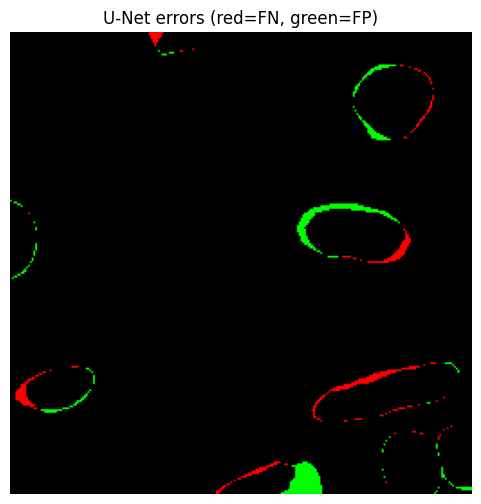

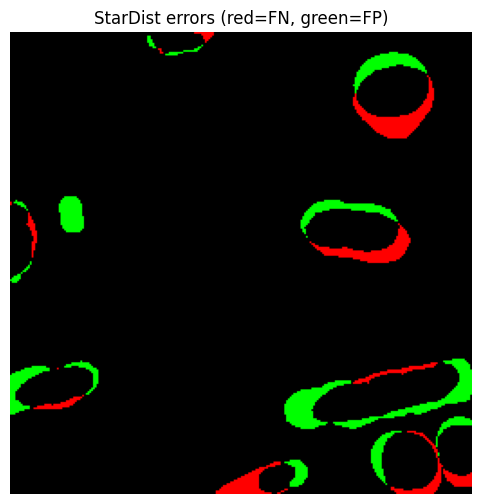

In [19]:
def show_error_map(gt_inst, pred_inst, title="Errors"):
    gt = gt_inst > 0
    pr = pred_inst > 0

    fp = pr & (~gt)
    fn = gt & (~pr)

    canvas = np.zeros((*gt.shape, 3), dtype=np.float32)
    canvas[..., 1] = fp.astype(np.float32)  # vert = FP (sur-seg)
    canvas[..., 0] = fn.astype(np.float32)  # rouge = FN (miss)
    plt.figure(figsize=(6,6))
    plt.imshow(canvas)
    plt.title(title + " (red=FN, green=FP)")
    plt.axis("off")
    plt.show()

show_error_map(gt_inst, pred_unet_inst, title="U-Net errors")
show_error_map(gt_inst, pred_sd_inst, title="StarDist errors")
